## 0. 전처리

### 0.0 model_df 불러오기

In [ ]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import platform

# 불필요한 경고문 생략
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정
def set_matplotlib_font():
    system = platform.system()

    if system == "Windows":
        plt.rc('font', family='Malgun Gothic')
    elif system == "Darwin":  # macOS
        plt.rc('font', family='AppleGothic')
    elif system == "Linux":
        plt.rc('font', family='NanumGothic')
    else:
        print("Unknown system. Please set font manually.")

    plt.rcParams['axes.unicode_minus'] = False

# 폰트 설정 함수 호출
set_matplotlib_font()

# 데이터 불러오기
df = pd.read_csv('./data/model_df_314.csv', encoding='cp949')

# '주차'를 기준으로 오름차순 정렬
df = df.sort_values(by='주차', ascending=True)
df['주차'] = pd.to_datetime(df['주차'])
df.reset_index(drop=True, inplace=True)

print('[행/컬럼 갯수]')
print(f"행: {df.shape[0]}, 컬럼: {df.shape[1]}\n")

### 0.1 기온, 날씨 카운트, 악천후일수 컬럼 생성(강한 비, 강한 눈 확인용)

In [ ]:
import pandas as pd

# 데이터 불러오기
file_path = "./data/서울_기온누적강수량.csv"
weather_df = pd.read_csv(file_path, encoding="cp949", parse_dates=["일시"])
weather_df
# 필요없는 컬럼 제거
weather_df = weather_df[['일시', '평균기온(°C)', '1시간 최다강수량(mm)', '일 최심신적설(cm)', '일강수량(mm)']]

# 컬럼명 변경
weather_df.rename(columns={'일 최심신적설(cm)': '최심신적설(cm)'}, inplace=True)

# '평균 날씨' 컬럼 생성 함수
def classify_weather(row):
    if pd.isna(row['1시간 최다강수량(mm)']) and pd.isna(row['최심신적설(cm)']):
        return '맑음'
    if pd.notna(row['1시간 최다강수량(mm)']) and row['1시간 최다강수량(mm)'] <= 1:
        return '흐림'
    if pd.isna(row['최심신적설(cm)']):
        if row['1시간 최다강수량(mm)'] > 15:
            return '강한 비'
        elif row['1시간 최다강수량(mm)'] > 0:
            return '비'
    if row['최심신적설(cm)'] > 5:
        return '강한 눈'
    if row['평균기온(°C)'] < 5:
        return '눈'
    return '진눈깨비'

# '평균 날씨' 컬럼 생성
weather_df['평균 날씨'] = weather_df.apply(classify_weather, axis=1)

# 2021년 1월 3일부터 시작하는 주차 컬럼 생성 (7일 간격)
weekly_dates = pd.date_range(start="2021-01-03", end=weather_df['일시'].max(), freq='7D')
# 각 날짜가 속한 주차 찾기
weather_df['주차'] = weather_df['일시'].apply(lambda x: weekly_dates[weekly_dates <= x].max())

# 주차별 기온 평균, 강수량 최대, 적설량 최대 계산
weekly_summary = weather_df.groupby('주차').agg({
    '평균기온(°C)': 'mean',
    '일강수량(mm)': 'sum',
    '최심신적설(cm)': 'max'
}).reset_index()

# NaN 값 0으로 채우기
weekly_summary[['일강수량(mm)', '최심신적설(cm)']] = weekly_summary[['일강수량(mm)', '최심신적설(cm)']].fillna(0)

# 평균 기온을 소수점 2자리로 반올림
weekly_summary['평균기온(°C)'] = weekly_summary['평균기온(°C)'].round(2)

# 주차별 날씨 상태 개수 카운트
weekly_weather_counts = weather_df.groupby(['주차', '평균 날씨']).size().unstack(fill_value=0).reset_index()

# '강한 비' + '강한 눈'을 합쳐 '악천후일수' 생성
weekly_weather_counts['악천후일수'] = weekly_weather_counts.get('강한 비', 0) + weekly_weather_counts.get('강한 눈', 0)

# 주차별 데이터 병합
weekly_weather_df = weekly_weather_counts.merge(weekly_summary, on='주차', how='left')

# 컬럼명 변경
weekly_weather_df.rename(columns={'평균기온(°C)': '평균기온(도)'}, inplace=True)

# 컬럼 순서 정리
columns_order = ['주차', '맑음', '흐림', '비', '강한 비', '눈', '강한 눈', '진눈깨비', '악천후일수', '평균기온(도)', '일강수량(mm)']
weekly_weather_df = weekly_weather_df[columns_order]

weekly_weather_df.sort_values(by='일강수량(mm)', ascending=False)

,기획년도,주차,카테고리,라인,시즌이월,시즌,복종,소품종,성별,총입고수량,...,ROI,맑음,흐림,비,강한 비,눈,강한 눈,진눈깨비,악천후일수,평균기온(도)
0,2021,2021-01-03,봄_가죽&FUR_가죽점퍼_ZA,ZA,01_시즌,봄,가죽&FUR,가죽점퍼,1:남성,1600,...,0.11,4,0,0,0,3,0,0,0,-9.1
1,2021,2021-01-03,사계절_우븐 셔츠_드레스셔츠_ZC,ZC,01_시즌,사계절,우븐 셔츠,드레스셔츠,1:남성,1000,...,0.06,4,0,0,0,3,0,0,0,-9.1
2,2021,2021-01-03,사계절_우븐 셔츠_드레스셔츠_ZB,ZB,01_시즌,사계절,우븐 셔츠,드레스셔츠,1:남성,101915,...,0.04,4,0,0,0,3,0,0,0,-9.1
3,2021,2021-01-03,사계절_수트_수트팬츠_ZB,ZB,01_시즌,사계절,수트,수트팬츠,1:남성,10099,...,0.17,4,0,0,0,3,0,0,0,-9.1
4,2021,2021-01-03,사계절_수트_블레이져(수트)_ZB,ZB,01_시즌,사계절,수트,블레이져(수트),1:남성,8419,...,0.12,4,0,0,0,3,0,0,0,-9.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8862,2024,2024-12-29,겨울_스웨터_T-에리_ZB,ZB,01_시즌,겨울,스웨터,T-에리,1:남성,16432,...,1.69,3,0,0,0,0,0,0,0,2.4
8863,2024,2024-12-29,겨울_스웨터_Turtle_ZB,ZB,01_시즌,겨울,스웨터,Turtle,1:남성,21528,...,1.46,3,0,0,0,0,0,0,0,2.4
8864,2024,2024-12-29,겨울_스웨터_VEST_ZB,ZB,01_시즌,겨울,스웨터,VEST,1:남성,2406,...,2.84,3,0,0,0,0,0,0,0,2.4
8865,2024,2024-12-29,겨울_스웨터_라운드_ZB,ZB,01_시즌,겨울,스웨터,라운드,1:남성,24858,...,1.24,3,0,0,0,0,0,0,0,2.4


In [4]:
df[df['악천후일수']>0]


,기획년도,주차,카테고리,라인,시즌이월,시즌,복종,소품종,성별,총입고수량,...,ROI,맑음,흐림,비,강한 비,눈,강한 눈,진눈깨비,악천후일수,평균기온(도)
890,2021,2021-06-27,여름_우븐 셔츠_드레스셔츠_ZB,ZB,01_시즌,여름,우븐 셔츠,드레스셔츠,1:남성,106473,...,1.06,2,1,3,1,0,0,0,1,24.6
891,2021,2021-06-27,여름_수트_수트팬츠_ZC,ZC,01_시즌,여름,수트,수트팬츠,1:남성,6336,...,1.53,2,1,3,1,0,0,0,1,24.6
892,2021,2021-06-27,여름_스웨터_T-에리_ZB,ZB,01_시즌,여름,스웨터,T-에리,1:남성,42085,...,1.96,2,1,3,1,0,0,0,1,24.6
893,2021,2021-06-27,여름_스웨터_라운드_ZB,ZB,01_시즌,여름,스웨터,라운드,1:남성,8080,...,2.82,2,1,3,1,0,0,0,1,24.6
894,2021,2021-06-27,여름_우븐 셔츠_캐쥬얼셔츠_ZB,ZB,01_시즌,여름,우븐 셔츠,캐쥬얼셔츠,1:남성,220857,...,0.66,2,1,3,1,0,0,0,1,24.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8667,2024,2024-11-24,겨울_니트 셔츠_티에리_ZA,ZA,01_시즌,겨울,니트 셔츠,티에리,1:남성,4024,...,0.97,4,0,0,0,0,2,1,2,3.8
8668,2024,2024-11-24,겨울_니트 셔츠_라운드_ZG,ZG,01_시즌,겨울,니트 셔츠,라운드,1:남성,5302,...,0.26,4,0,0,0,0,2,1,2,3.8
8669,2024,2024-11-24,겨울_니트 셔츠_라운드_ZB,ZB,01_시즌,겨울,니트 셔츠,라운드,1:남성,21140,...,1.04,4,0,0,0,0,2,1,2,3.8
8670,2024,2024-11-24,겨울_니트 셔츠_라운드_ZA,ZA,01_시즌,겨울,니트 셔츠,라운드,1:남성,6016,...,1.16,4,0,0,0,0,2,1,2,3.8


# summer_pants

<Axes: >

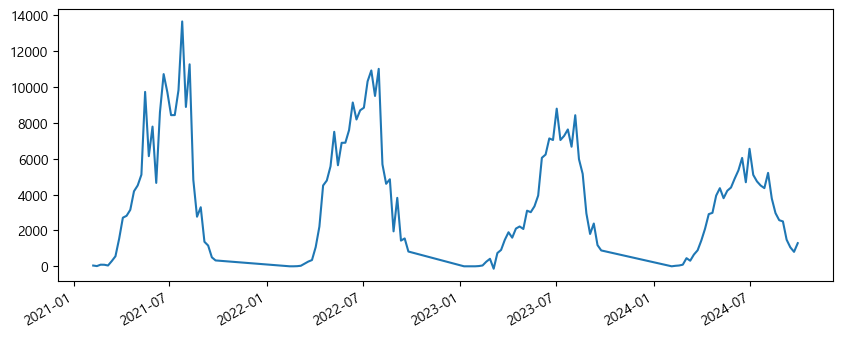

In [115]:
# 여름 팬츠만 골라서 주차별 판매수량 합치기
summer_pants = df[(df['복종'] == '팬츠') & (df['시즌'] == '여름')]
summer_pants_df = summer_pants.groupby('주차', as_index=False)['판매수량'].sum()

# '주차'를 인덱스로 설정
summer_pants_df.set_index('주차', inplace=True)
# 인덱스명 제거
summer_pants_df.index.name = None
summer_pants_df = summer_pants_df['판매수량']  # '판매수량' 컬럼만 선택
summer_pants_df.plot(figsize=(10,4)) #시각화

## 1. S-ARIMA

### 1.1 정상성 검정(ADF/KPSS) + 차수 결정(ACF/PACF) + 데이터 분할(훈련/평가 데이터)

In [116]:
import statsmodels.api as sm
from statsmodels.tsa.stattools import kpss

def get_test(df):
# 정상성 검사를 위한 ADF Test 실행
    adf_test = sm.tsa.adfuller(df)
    print(f'ADF Statistic:{adf_test[0]:.3f}')
    print(f'p-value:{adf_test[1]:.3f}')

    kpss_test = kpss(df, regression='ct')  # 'c'는 상수 포함, 'ct'는 상수 및 추세 포함
    print(f'KPSS Statistic:{kpss_test[0]:.3f}')
    print(f'p-value:{kpss_test[1]:.3f}')
    
get_test(summer_pants_df)

ADF Statistic:-4.987
p-value:0.000
KPSS Statistic:0.046
p-value:0.100


- ADF 검정 결과
- ADF 테스트는 귀무 가설이 "데이터가 비정상성이다"라고 가정.
여기서 p-value가 0.05보다 작기 때문에, 귀무 가설 기각. 즉, 정상성을 띈다.

- KPSS 검정 결과
- KPSS 테스트는 귀무 가설이 "데이터가 정상성이다"라고 가정.
여기서 p-value가 0.05보다 크기 때문에, 귀무 가설 채택. 즉, 정상성을 띈다.

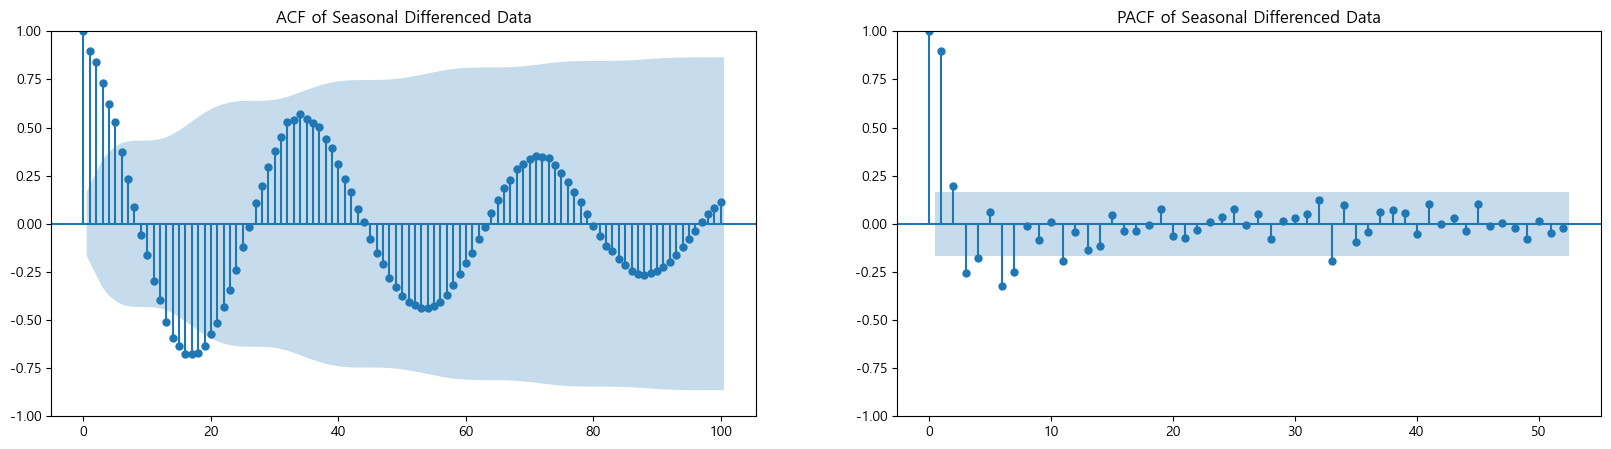

In [117]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(1, 2, figsize=(20, 5))

plot_acf(summer_pants_df, lags=100, ax=axes[0])
axes[0].set_title('ACF of Seasonal Differenced Data')

max_lags = min(len(summer_pants_df) // 2, 52)  # 최대 데이터 개수의 50%로 제한

plot_pacf(summer_pants_df, lags=max_lags, ax=axes[1])
axes[1].set_title('PACF of Seasonal Differenced Data')

plt.show()

- 비계절 차분: 추세(Trend)를 제거하기 위한 차분

    - p(비계절 이동평균 차수): PACF에서는 시차 1에서 매우 높은 상관관계 보임. p=1
    - d(비계절 차분 차수): 정상성 검정 결과 일반 차분은 필요 없으므로 d=0으로 설정.
    - q(비계절 이동 평균 차수): ACF에서 주기적인 변동이 강하므로 비계절적 이동평균이 아님. q = 0 


- 계절 차분: 계절성을 제거하기 위한 단계
    - P(계절 자기회귀 차수): PACF에서 **52주 주기에 명확한 피크가 없으므로 계절적인 자기 회귀 항(P)은 0**
    - D(계절 차분 차수): 정상성 검정 결과 정상시계열로 판단되었지만, ACF에서 계절적 패턴이 매우 강하므로 계절 차분 시도(실제 성능좋음) D = 1
    - Q(계절 이동평균 차수): ACF에서 52주 주기마다 반복되는 패턴을 보이므로 Q=1
    - m(계절주기): **계절성 주기(m)**는 주간 데이터이므로 m=52(52주)로 설정


In [118]:
# 전체 데이터의 길이 확인
total_len = len(summer_pants_df)

# 주차(날짜)가 인덱스라면, datetime 형식으로 변환
summer_pants_df.index = pd.to_datetime(summer_pants_df.index)

# 훈련 데이터 (2021~2023년)
train_data = summer_pants_df.loc['2021':'2023']

# 평가 데이터 (2024년)
test_data = summer_pants_df.loc['2024']

# 데이터 길이 확인
print(total_len, len(train_data), len(test_data))


140 105 35


### 1.2 SARIMA 모델링

- SARIMAX의 "X"는 **외생 변수(Exogenous variables)**를 포함할 수 있다는 의미. 만약 외생 변수를 사용하지 않으면 SARIMA와 동일하게 작동.

In [119]:
%%time

from statsmodels.tsa.statespace.sarimax import SARIMAX

# SARIMA 모델 적합
sarima_model = SARIMAX(train_data,
                       order=(1, 0, 0),  # p, d, q
                       seasonal_order=(0, 1, 1, 52))  # P, D, Q, m (주기 52주)
sarima_model = sarima_model.fit()
sarima_model.summary()


CPU times: total: 8.67 s
Wall time: 4.87 s


<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                       
============================================================================================
Dep. Variable:                                 판매수량   No. Observations:                  105
Model:             SARIMAX(1, 0, 0)x(0, 1, [1], 52)   Log Likelihood                -472.902
Date:                              Fri, 14 Mar 2025   AIC                            951.805
Time:                                      17:54:12   BIC                            957.716
Sample:                                           0   HQIC                           954.078
                                              - 105                                         
Covariance Type:                                opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9144      0.052     17.424      0.000       0.812       1.017
ma.S.L52      -0.9887      0.250     -3.947      0.000      -1.480      -0.498
sigma2      2.304e+06   1.08e-07   2.12e+13      0.000     2.3e+06     2.3e+06
===================================================================================
Ljung-Box (L1) (Q):                   1.61   Jarque-Bera (JB):                 1.72
Prob(Q):                              0.20   Prob(JB):                         0.42
Heteroskedasticity (H):               0.57   Skew:                            -0.44
Prob(H) (two-sided):                  0.24   Kurtosis:                         2.91
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
[2] Covariance matrix is singular or near-singular, with condition number 1.66e+29. Standard errors may be unstable.
"""

### 1.3 SARIMA 예측 + 성능 확인 + 잔차분석

In [120]:
# 테스트 데이터에 대해 예측 수행
n_periods = len(test_data)
sarima_forecast = sarima_model.get_forecast(steps=n_periods)

# 예측값
forecast_values = sarima_forecast.predicted_mean

# 신뢰 구간
conf_int = sarima_forecast.conf_int()

forecast_values.head(3)

105    1206.952987
106    1392.671602
107    2073.675595
Name: predicted_mean, dtype: float64

In [121]:
from sklearn.metrics import mean_squared_error
import numpy as np

def get_metrics(test_data, forecast):
    # MSE (Mean Squared Error) 계산
    mse = mean_squared_error(test_data, forecast)
    print(f'MSE: {mse:.3f}')

    # RMSE (Root Mean Squared Error) 계산
    rmse = np.sqrt(mse)
    print(f'RMSE: {rmse:.3f}')

    # MAPE (Mean Absolute Percentage Error) 계산 (분모가 0인 경우 무시)
    epsilon = 1e-10  # 0으로 나누면 분모에 0이 들어가면서 inf 또는 NaN이 발생할 수 있음.
    #이를 방지하기 위해 작은 값 추가!
    mape = np.mean(np.abs((test_data - forecast) / (test_data + epsilon))) * 100
    print(f'MAPE: {mape:.3f}%')
    
get_metrics(test_data, forecast_values)

MSE: 3732485.876
RMSE: 1931.964
MAPE: nan%


In [122]:
from statsmodels.stats.diagnostic import acorr_ljungbox

# Ljung-Box 검정 (잔차의 독립성 검정)
ljung_box_test = acorr_ljungbox(sarima_model.resid, lags=[10], return_df=True)
print(ljung_box_test)

      lb_stat  lb_pvalue
10  29.291042   0.001118


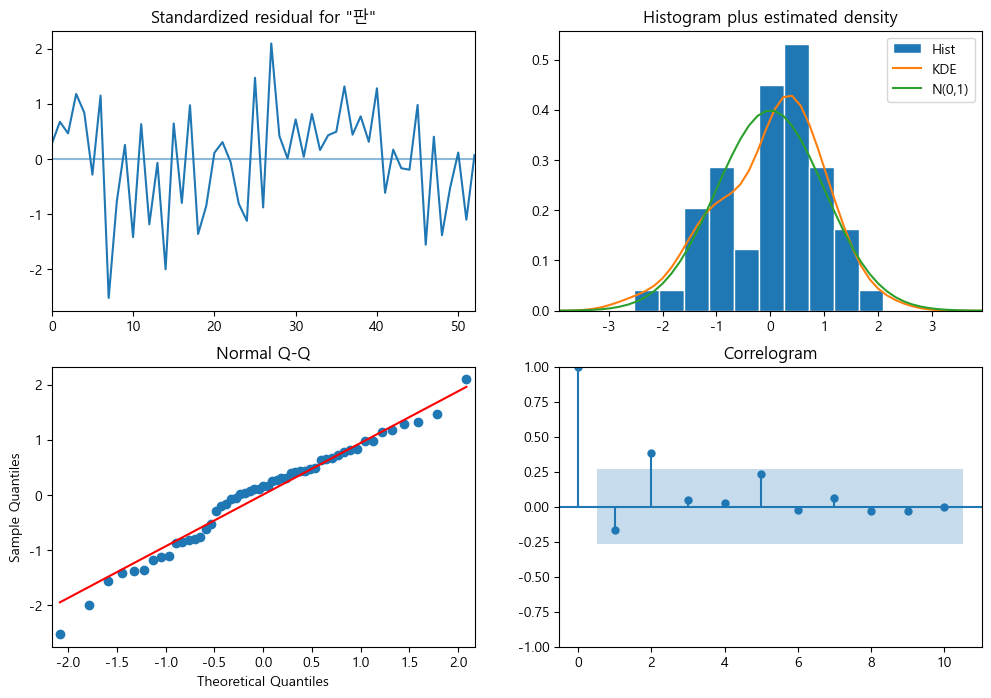

In [123]:
# 모델의 잔차 분석
sarima_model.plot_diagnostics(figsize=(12, 8))
plt.show()

### 1.4 SARIMA 예측결과 시각화

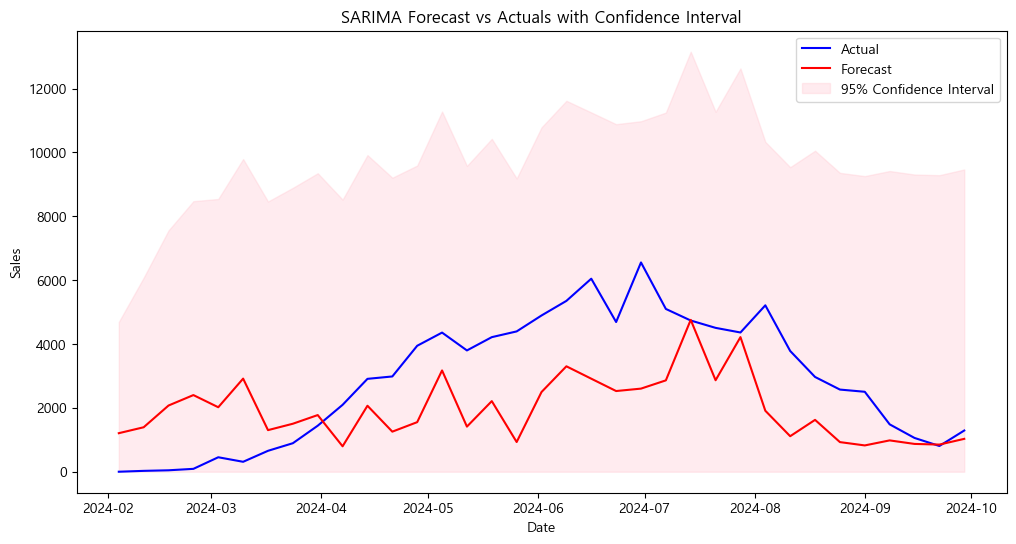

In [124]:
plt.figure(figsize=(12, 6))

# 실제 값
plt.plot(test_data.index, test_data, label='Actual', color='blue')

# 예측 값
plt.plot(test_data.index, forecast_values, label='Forecast', color='red')

# 신뢰 구간 (하한값을 0 이상으로 설정)
plt.fill_between(test_data.index, np.maximum(conf_int.iloc[:, 0], 0), conf_int.iloc[:, 1], color='pink', alpha=0.3, label='95% Confidence Interval')

plt.title('SARIMA Forecast vs Actuals with Confidence Interval')
plt.xlabel('Date')
plt.ylabel('Sales')  # Y축 레이블을 'Temperature' 대신 'Sales'로 변경
plt.legend()
plt.show()


## 2. Auto-ARIMA

In [125]:
# %%time

# from pmdarima.arima import auto_arima

# auto_arima_model = auto_arima(
#     summer_pants_df,
#     seasonal=True,             # 계절성 모델 적용
#     m=52,                      # 주간 데이터에서는 계절 주기를 52로 설정 (1년 = 52주)
#     stepwise=True,             # 단계별 탐색으로 빠른 계산
#     trace=True,                # 모델 피팅 과정 출력
#     error_action='ignore',     # 모델 피팅 중 에러 무시
#     suppress_warnings=True,    # 경고 메시지 숨김
#     max_order=10,              # 최대 차수 제한
#     start_p=1, start_q=1,      # p와 q의 초기 값
#     max_p=3, max_q=3,          # p와 q의 최대 값
#     start_P=0, start_Q=0,      # 계절적 P와 Q의 초기 값
#     max_P=2, max_Q=2,          # 계절적 P와 Q의 최대 값
#     d=None, D=1,               # 차분(d)은 자동 선택, 계절 차분(D)은 1
# )

# auto_arima_model.summary()

In [126]:
# # 전체 데이터의 길이 확인
# total_len = len(summer_pants_df)

# # 주차(날짜)가 인덱스라면, datetime 형식으로 변환
# summer_pants_df.index = pd.to_datetime(summer_pants_df.index)

# # 훈련 데이터 (2021~2023년)
# train_data = summer_pants_df.loc['2021':'2023']

# # 평가 데이터 (2024년)
# test_data = summer_pants_df.loc['2024']

# # 데이터 길이 확인
# print(total_len, len(train_data), len(test_data))

In [127]:
# auto_arima_model.fit(train_data)

In [128]:
# print(test_data)

In [129]:
# forecast = auto_arima_model.predict(n_periods=len(test_data))

# # 예측 실행
# forecast_values = auto_arima_model.predict(n_periods=len(test_data))

# # 예측값 확인
# print(forecast_values)

# # 예측값이 None인지 체크
# if forecast_values is None or all(pd.isna(forecast_values)):
#     print("예측값이 NaN입니다. 데이터와 모델을 확인하세요.")
# else:
#     forecast_index = pd.to_datetime(forecast_index)  # 날짜 타입 강제 변환
#     forecast = pd.Series(forecast_values, index=forecast_index)


# forecast.tail()

In [130]:
# print("forecast_values:")
# print(forecast_values)

# print("\nforecast_index:")
# print(forecast_index)

# # NaN 발생 문제 디버깅
# forecast = pd.Series(forecast_values, index=forecast_index)
# print("\nGenerated forecast series:")
# print(forecast)


In [131]:
# print(len(forecast_values), len(forecast_index))


In [132]:
# forecast

In [133]:
# from sklearn.metrics import mean_squared_error
# import numpy as np

# def get_metrics(test_data, forecast):
#     # MSE (Mean Squared Error) 계산
#     mse = mean_squared_error(test_data, forecast)
#     print(f'MSE: {mse:.3f}')

#     # RMSE (Root Mean Squared Error) 계산
#     rmse = np.sqrt(mse)
#     print(f'RMSE: {rmse:.3f}')

#     # MAPE (Mean Absolute Percentage Error) 계산 (분모가 0인 경우 무시)
#     epsilon = 1e-10  # 0으로 나누면 분모에 0이 들어가면서 inf 또는 NaN이 발생할 수 있음.
#     #이를 방지하기 위해 작은 값 추가!
#     mape = np.mean(np.abs((test_data - forecast) / (test_data + epsilon))) * 100
#     print(f'MAPE: {mape:.3f}%')

# get_metrics(test_data, forecast)

In [134]:
# import matplotlib.pyplot as plt

# auto_arima_model.plot_diagnostics(figsize=(10, 6))
# plt.subplots_adjust(hspace=0.5)
# for ax in plt.gcf().axes:  # 현재 figure의 모든 axes에 적용
#     plt.sca(ax)  # 해당 서브플롯 선택
#     plt.xticks(rotation=45)  # x축 라벨 기울이기
    
# plt.show()


In [135]:
# #잔차계산
# residuals = test_data - forecast
# residuals.tail()

# 사계절_데님팬츠_ZB

In [136]:
# 여름 팬츠만 골라서 주차별 판매수량 합치기
denim_pants = df[df['카테고리']=='사계절_데님_데님팬츠_ZB']
denim_pants_df = denim_pants.groupby('주차', as_index=False)['판매수량'].sum()

# '주차'를 인덱스로 설정
denim_pants_df.set_index('주차', inplace=True)
# 인덱스명 제거
denim_pants_df.index.name = None
denim_pants_df = denim_pants_df['판매수량']  # '판매수량' 컬럼만 선택
# denim_pants_df.plot(figsize=(20,6)) #시각화

## 3. Prophet

In [137]:
# Series를 DataFrame으로 변환하고 컬럼명 변경
denim_pants_df = denim_pants_df.to_frame().reset_index()
denim_pants_df.columns = ['ds', 'y']
# denim_pants_df

In [138]:
# datetime 맞는지 확인인
denim_pants_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   ds      200 non-null    datetime64[ns]
 1   y       200 non-null    int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 3.2 KB


<Axes: xlabel='ds'>

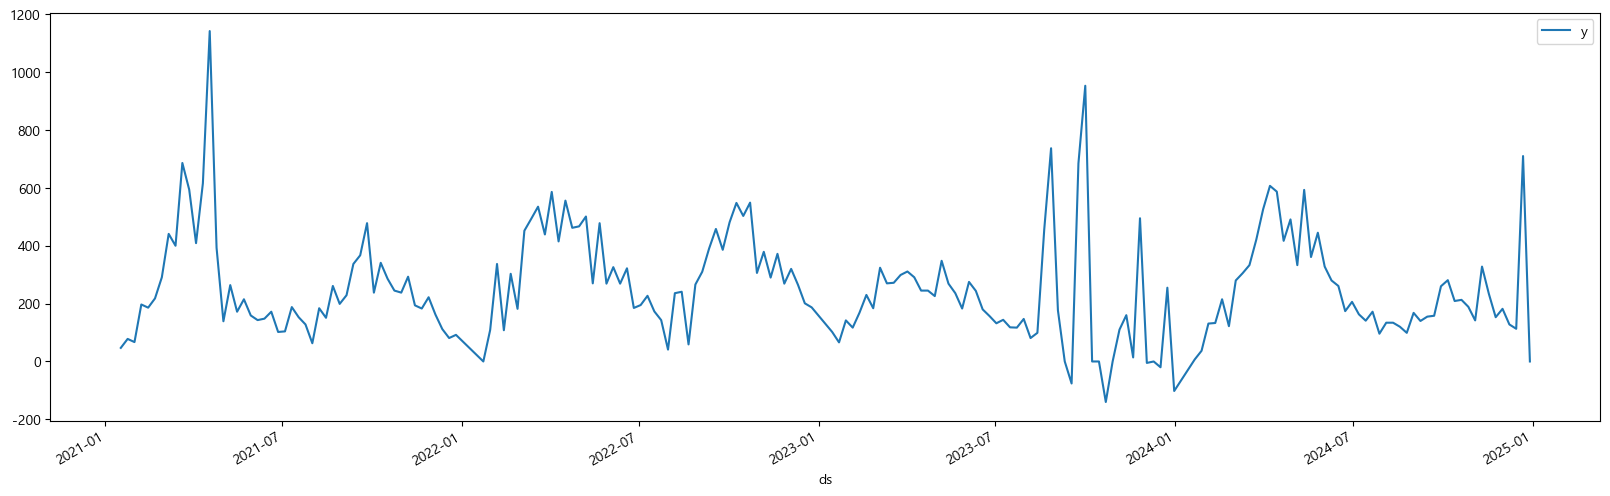

In [139]:
# 한번 더 시각화, 봄에 매출이 높고 7월쯤 매출이 떨어지다가 가을에 또 상승하는 패턴이 보임
denim_pants_df.plot(x='ds', y='y', figsize=(20,6))

In [140]:
# 전체 데이터의 길이 확인
total_len = len(denim_pants_df)
# 훈련 데이터 (2021~2023년)
train_data = denim_pants_df[(denim_pants_df['ds'].dt.year >= 2021) & (denim_pants_df['ds'].dt.year <= 2023)]
# 평가 데이터 (2024년)
test_data = denim_pants_df[denim_pants_df['ds'].dt.year == 2024]

# 데이터 길이 확인
print(total_len, len(train_data), len(test_data))

200 150 50


In [141]:
from prophet import Prophet

#계절성 모드는 곱셈 모델을 사용해야 시간에 따라 증가하는 것을 학습가능
m = Prophet(changepoint_prior_scale=0.1,
            yearly_seasonality=True)#seasonality_mode='multiplicative')
m.fit(train_data)

17:54:13 - cmdstanpy - INFO - Chain [1] start processing
17:54:13 - cmdstanpy - INFO - Chain [1] done processing


In [142]:
future = m.make_future_dataframe(periods=52, freq='W')  # freq='W'로 주간 데이터 생성
future

,ds
0,2021-01-17
1,2021-01-24
2,2021-01-31
3,2021-02-07
4,2021-02-14
...,...
197,2024-12-01
198,2024-12-08
199,2024-12-15
200,2024-12-22


In [143]:
# future = test_data[['ds']] # 평가데이터수 만큼 예측
forecast = m.predict(future)
forecast

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2021-01-17,263.348626,-144.106907,223.756184,263.348626,263.348626,-213.662270,-213.662270,-213.662270,-213.662270,-213.662270,-213.662270,0.0,0.0,0.0,49.686356
1,2021-01-24,263.468627,-93.624455,267.187728,263.468627,263.468627,-171.611558,-171.611558,-171.611558,-171.611558,-171.611558,-171.611558,0.0,0.0,0.0,91.857069
2,2021-01-31,263.588628,-34.506949,321.352588,263.588628,263.588628,-127.517574,-127.517574,-127.517574,-127.517574,-127.517574,-127.517574,0.0,0.0,0.0,136.071054
3,2021-02-07,263.708630,-3.598960,347.683014,263.708630,263.708630,-95.496699,-95.496699,-95.496699,-95.496699,-95.496699,-95.496699,0.0,0.0,0.0,168.211931
4,2021-02-14,263.828631,19.254916,387.426203,263.828631,263.828631,-68.260548,-68.260548,-68.260548,-68.260548,-68.260548,-68.260548,0.0,0.0,0.0,195.568083
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
197,2024-12-01,96.399663,-147.609509,234.556776,87.438068,105.305534,-53.022400,-53.022400,-53.022400,-53.022400,-53.022400,-53.022400,0.0,0.0,0.0,43.377263
198,2024-12-08,94.844595,-166.601538,195.532194,85.598827,104.069049,-75.122289,-75.122289,-75.122289,-75.122289,-75.122289,-75.122289,0.0,0.0,0.0,19.722306
199,2024-12-15,93.289527,-177.216754,190.316772,83.838936,102.799488,-88.191954,-88.191954,-88.191954,-88.191954,-88.191954,-88.191954,0.0,0.0,0.0,5.097573
200,2024-12-22,91.734458,-204.873368,162.823269,81.912471,101.473330,-117.406955,-117.406955,-117.406955,-117.406955,-117.406955,-117.406955,0.0,0.0,0.0,-25.672496


In [144]:
#- yhat은 예측된 값이며, yhat_lower와 yhat_upper는 95% 신뢰 구간을 의미. 즉, 예측된 값의 불확실성을 보여줌
forecast[['ds', 'yhat_lower', 'yhat_upper', 'yhat']]

,ds,yhat_lower,yhat_upper,yhat
0,2021-01-17,-144.106907,223.756184,49.686356
1,2021-01-24,-93.624455,267.187728,91.857069
2,2021-01-31,-34.506949,321.352588,136.071054
3,2021-02-07,-3.598960,347.683014,168.211931
4,2021-02-14,19.254916,387.426203,195.568083
...,...,...,...,...
197,2024-12-01,-147.609509,234.556776,43.377263
198,2024-12-08,-166.601538,195.532194,19.722306
199,2024-12-15,-177.216754,190.316772,5.097573
200,2024-12-22,-204.873368,162.823269,-25.672496


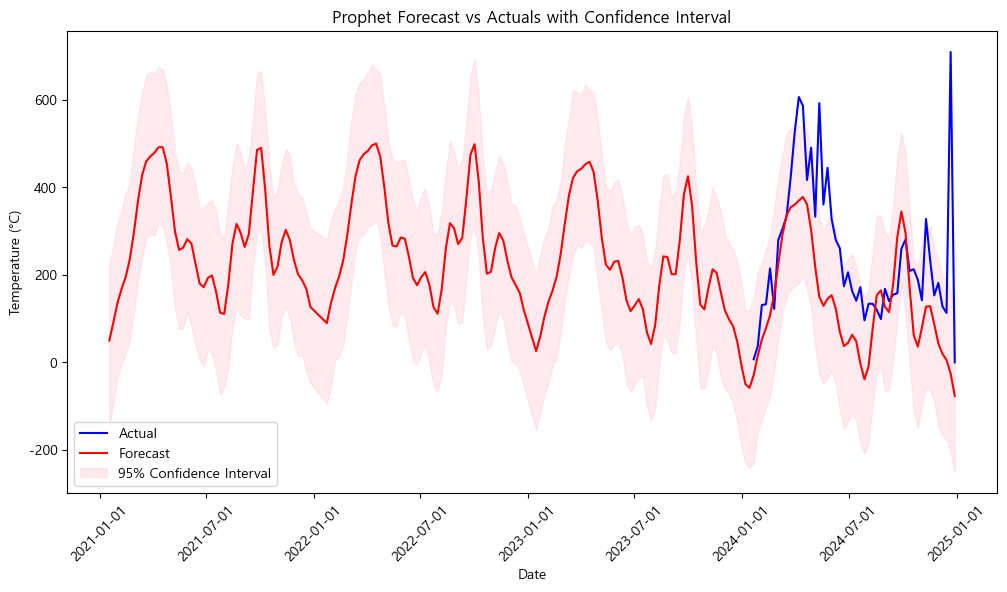

In [145]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Prophet 예측 시각화
plt.figure(figsize=(12, 6))

# 실제 값 (Actual)
plt.plot(test_data['ds'], test_data['y'], label='Actual', color='blue')
# 예측 값 (Forecast)
plt.plot(forecast['ds'], forecast['yhat'], label='Forecast', color='red')
# 신뢰 구간 (Confidence Interval)
plt.fill_between(forecast['ds'], forecast['yhat_lower'], forecast['yhat_upper'], color='pink', alpha=0.3, label='95% Confidence Interval')

# 그래프 설정
plt.title('Prophet Forecast vs Actuals with Confidence Interval')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.legend()

# X축 레이블 각도 조정
plt.xticks(rotation=45)
# 날짜 포맷 설정
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
# 그래프 출력
plt.show()

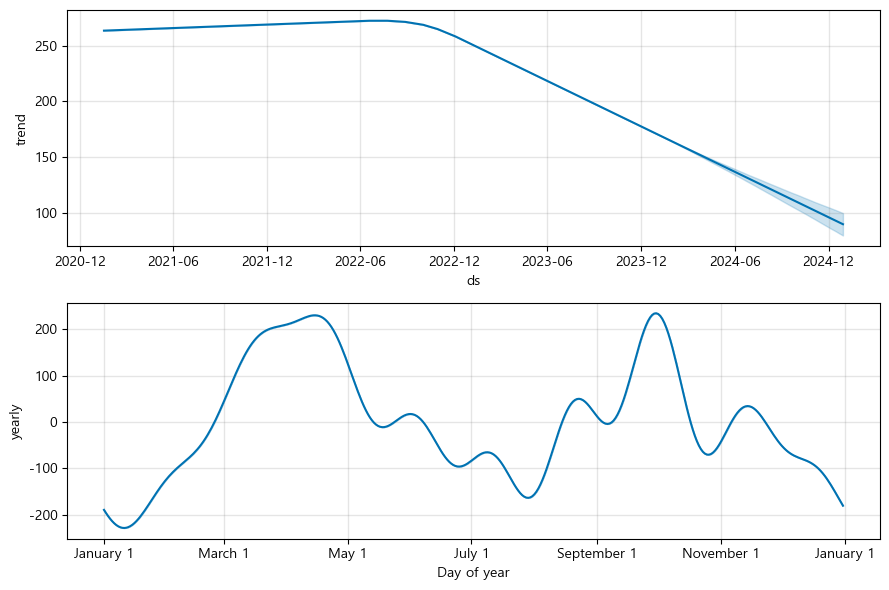

In [146]:
m.plot_components(forecast); #추세선과 연간계절성 시각화

In [147]:
# 원래데이터와 forecast 데이터를 날짜를 기준으로 병합
# 원래데이터에 예측값인 yhat을 ds기준(조인 기준)으로 inner 조인하기
merged_data = pd.merge(denim_pants_df[['ds', 'y']], forecast[['ds', 'yhat']], on='ds', how='inner')
# 잔차 계산!
merged_data['residual'] = merged_data['y'] - merged_data['yhat']
merged_data

,ds,y,yhat,residual
0,2021-01-17,47,49.686356,-2.686356
1,2021-01-24,78,91.857069,-13.857069
2,2021-01-31,67,136.071054,-69.071054
3,2021-02-07,197,168.211931,28.788069
4,2021-02-14,186,195.568083,-9.568083
...,...,...,...,...
195,2024-12-01,182,43.377263,138.622737
196,2024-12-08,128,19.722306,108.277694
197,2024-12-15,113,5.097573,107.902427
198,2024-12-22,710,-25.672496,735.672496


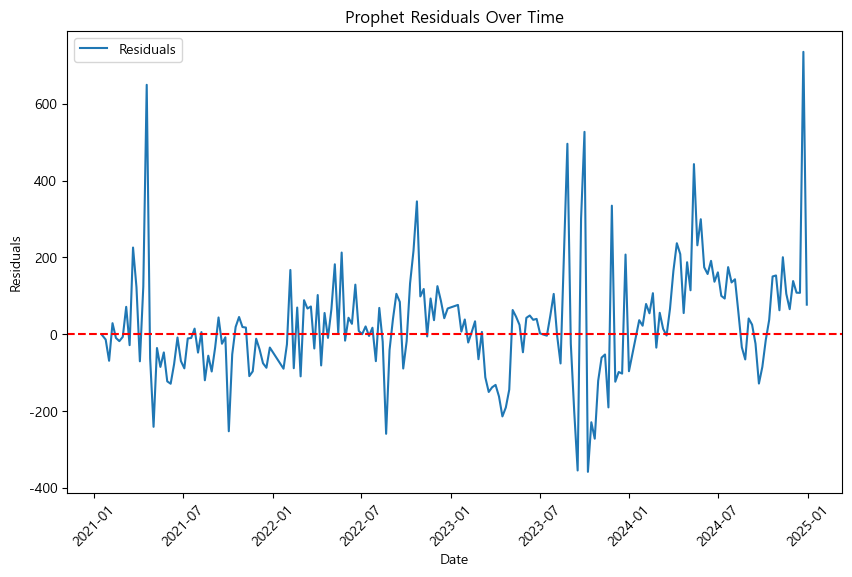

In [148]:
# 잔차 시각화
plt.figure(figsize=(10,6))
plt.plot(merged_data['ds'], merged_data['residual'], label='Residuals')
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Prophet Residuals Over Time')
plt.xlabel('Date')
plt.ylabel('Residuals')
plt.xticks(rotation=45)
plt.legend()
plt.show()

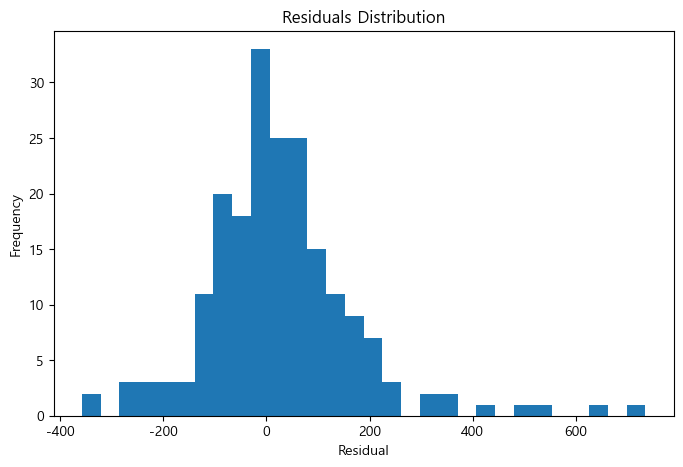

In [149]:
# 잔차 히스토그램
plt.figure(figsize=(8,5))
plt.hist(merged_data['residual'], bins=30)
plt.title('Residuals Distribution')
plt.xlabel('Residual')
plt.ylabel('Frequency')
plt.show()


In [150]:
from statsmodels.stats.diagnostic import acorr_ljungbox

# Ljung-Box 테스트
ljung_test = acorr_ljungbox(merged_data['residual'], lags=[10], return_df=True)
print(ljung_test)

      lb_stat     lb_pvalue
10  63.626033  7.417722e-10


- 현재 Ljung-Box 테스트 결과에서 p-value가 0.05보다 매우 작다. 따라서 모델의 잔차가 무작위(백색소음)가 아니다....ㅠ

In [151]:
get_metrics(merged_data['y'], merged_data['yhat'])

MSE: 22198.696
RMSE: 148.992
MAPE: 5879600779154.446%


18:00:00 - cmdstanpy - INFO - Chain [1] start processing
18:00:00 - cmdstanpy - INFO - Chain [1] done processing


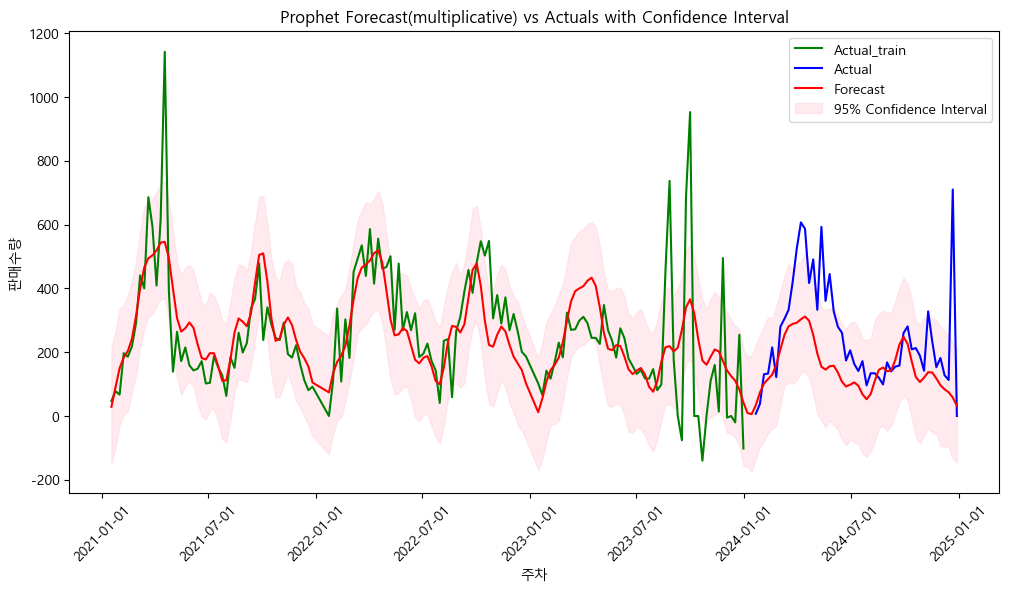

In [155]:
#계절성 모드는 곱셈 모델을 사용해야 시간에 따라 증가하는 것을 학습가능
m = Prophet(changepoint_prior_scale=0.1,
            yearly_seasonality=True, seasonality_mode='multiplicative')
m.fit(train_data)

future = m.make_future_dataframe(periods=52, freq='W')  # freq='W'로 주간 데이터 생성
forecast = m.predict(future) # 예측

# Prophet 예측 시각화
plt.figure(figsize=(12, 6))

# 실제 값 (Actual)
plt.plot(train_data['ds'], train_data['y'], label='Actual_train', color='green')
# 실제 값 (Actual)
plt.plot(test_data['ds'], test_data['y'], label='Actual', color='blue')
# 예측 값 (Forecast)
plt.plot(forecast['ds'], forecast['yhat'], label='Forecast', color='red')
# 신뢰 구간 (Confidence Interval)
plt.fill_between(forecast['ds'], forecast['yhat_lower'], forecast['yhat_upper'], color='pink', alpha=0.3, label='95% Confidence Interval')
# 그래프 설정
plt.title('Prophet Forecast(multiplicative) vs Actuals with Confidence Interval')
plt.xlabel('주차')
plt.ylabel('판매수량')
plt.legend()

# X축 레이블 각도 조정
plt.xticks(rotation=45)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))

# 그래프 출력
plt.show()

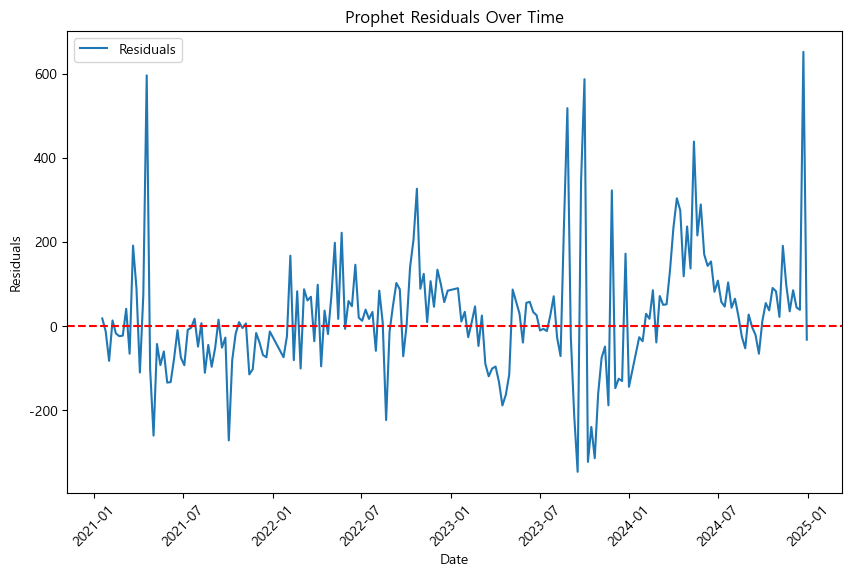

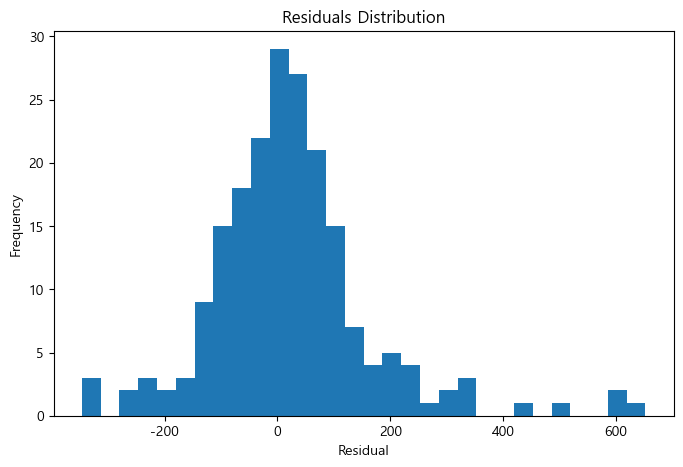

In [153]:
# 원래데이터에 예측값인 yhat을 ds기준(조인 기준)으로 inner 조인하기
merged_data = pd.merge(denim_pants_df[['ds', 'y']], forecast[['ds', 'yhat']], on='ds', how='inner')
# 잔차 계산!
merged_data['residual'] = merged_data['y'] - merged_data['yhat']
# 잔차 시각화
plt.figure(figsize=(10,6))
plt.plot(merged_data['ds'], merged_data['residual'], label='Residuals')
plt.axhline(y=0, color='r', linestyle='--')
plt.title('Prophet Residuals Over Time')
plt.xlabel('Date')
plt.ylabel('Residuals')
plt.xticks(rotation=45)
plt.legend()
plt.show()

# 잔차 히스토그램
plt.figure(figsize=(8,5))
plt.hist(merged_data['residual'], bins=30)
plt.title('Residuals Distribution')
plt.xlabel('Residual')
plt.ylabel('Frequency')
plt.show()

In [154]:
# Ljung-Box 테스트
ljung_test = acorr_ljungbox(merged_data['residual'], lags=[10], return_df=True)
print(ljung_test)

# 성능 분석
get_metrics(merged_data['y'], merged_data['yhat'])

      lb_stat     lb_pvalue
10  63.535138  7.719826e-10
MSE: 21295.615
RMSE: 145.930
MAPE: 5842519368893.089%


18:34:06 - cmdstanpy - INFO - Chain [1] start processing



🔹 Testing changepoint_prior_scale = 0.001...


18:34:06 - cmdstanpy - INFO - Chain [1] done processing
18:34:06 - cmdstanpy - ERROR - Chain [1] error: error during processing Operation not permitted
Optimization terminated abnormally. Falling back to Newton.
18:34:06 - cmdstanpy - INFO - Chain [1] start processing
18:34:07 - cmdstanpy - INFO - Chain [1] done processing
18:34:07 - cmdstanpy - INFO - Chain [1] start processing



🔹 Testing changepoint_prior_scale = 0.01...


18:34:07 - cmdstanpy - INFO - Chain [1] done processing
18:34:07 - cmdstanpy - INFO - Chain [1] start processing
18:34:07 - cmdstanpy - INFO - Chain [1] done processing


...


🔹 Testing changepoint_prior_scale = 5.0...


18:34:09 - cmdstanpy - INFO - Chain [1] done processing
18:34:09 - cmdstanpy - INFO - Chain [1] start processing



🔹 Testing changepoint_prior_scale = 10.0...


18:34:09 - cmdstanpy - INFO - Chain [1] done processing



🔥 최적의 changepoint_prior_scale 값 (MSE 기준): 0.01
📉 최적 모델의 MSE: 18861.449211113595

📊 CPS 성능 비교 결과:
      CPS           MSE        RMSE
1   0.010  18861.449211  137.336991
0   0.001  20252.684654  142.311927
2   0.050  22181.834832  148.935673
3   0.100  30129.888450  173.579631
6   5.000  30320.805439  174.128704
5   1.000  37393.100446  193.372957
7  10.000  45477.297269  213.254067
4   0.500  52926.954571  230.058589


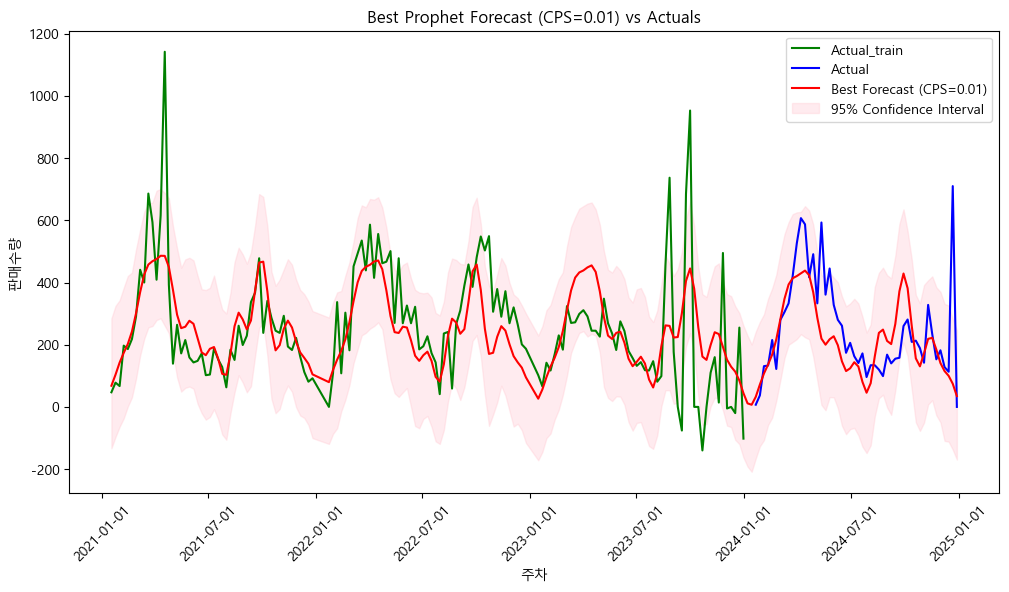

In [165]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from prophet import Prophet
from sklearn.metrics import mean_squared_error

# 테스트할 changepoint_prior_scale 값 리스트
cps_values = [0.001, 0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0]

# 최적값 저장 변수
best_cps = None
best_mse = float('inf')  # MSE가 낮을수록 좋음
best_forecast = None

# 결과 저장용 리스트
results = []

# ⚠️ 0값 대체 (epsilon 사용)
epsilon = 1e-10
test_data['y'] = test_data['y'].replace(0, epsilon)

# 평가 함수 (MSE, RMSE)
def get_metrics(merged_data):
    mse = mean_squared_error(merged_data['y'], merged_data['yhat'])
    rmse = np.sqrt(mse)
    return mse, rmse

# 다양한 `changepoint_prior_scale` 값을 테스트
for cps in cps_values:
    print(f"\n🔹 Testing changepoint_prior_scale = {cps}...")

    # Prophet 모델 생성 및 학습
    m = Prophet(changepoint_prior_scale=cps, yearly_seasonality=True)
                # , seasonality_mode='multiplicative')
    m.fit(train_data)

    # 🔥 전체 기간 예측 수행 (미래 데이터 생성)
    future = m.make_future_dataframe(periods=52, freq='W')  # 전체 데이터 예측
    forecast = m.predict(future)

    # 📌 원래 데이터와 예측값을 ds 기준으로 병합
    merged_data = pd.merge(denim_pants_df[['ds', 'y']], forecast[['ds', 'yhat']], on='ds', how='inner')

    # ✅ 테스트 데이터 구간만 필터링하여 평가 (동일 개수로 맞춤)
    test_merged = merged_data[merged_data['ds'].isin(test_data['ds'])]

    # 성능 평가 (MSE, RMSE)
    mse, rmse = get_metrics(test_merged)
    results.append((cps, mse, rmse, forecast))  # 예측 결과 저장

    # 최적 모델 업데이트 (MSE가 가장 낮은 모델 선택)
    if mse < best_mse:
        best_mse = mse
        best_cps = cps
        best_forecast = forecast

# 결과 정렬 후 출력 (MSE 기준)
results_df = pd.DataFrame(results, columns=["CPS", "MSE", "RMSE", "Forecast"])
results_df.sort_values(by="MSE", inplace=True)

# 최적의 prior_scale 출력
print("\n🔥 최적의 changepoint_prior_scale 값 (MSE 기준):", best_cps)
print("📉 최적 모델의 MSE:", best_mse)

# 최적 모델 가져오기
best_forecast = results_df.iloc[0]["Forecast"]

# 📊 결과 테이블 출력 (예측 데이터 제외)
print("\n📊 CPS 성능 비교 결과:")
print(results_df.drop(columns=["Forecast"]))  

# 🎯 최적 모델의 예측 시각화
plt.figure(figsize=(12, 6))
plt.plot(train_data['ds'], train_data['y'], label='Actual_train', color='green')
plt.plot(test_data['ds'], test_data['y'], label='Actual', color='blue')
plt.plot(best_forecast['ds'], best_forecast['yhat'], label=f'Best Forecast (CPS={best_cps})', color='red')
plt.fill_between(best_forecast['ds'], best_forecast['yhat_lower'], best_forecast['yhat_upper'], color='pink', alpha=0.3, label='95% Confidence Interval')

plt.title(f'Best Prophet Forecast (CPS={best_cps}) vs Actuals')
plt.xlabel('주차')
plt.ylabel('판매수량')
plt.legend()
plt.xticks(rotation=45)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.show()


18:34:28 - cmdstanpy - INFO - Chain [1] start processing
18:34:28 - cmdstanpy - INFO - Chain [1] done processing


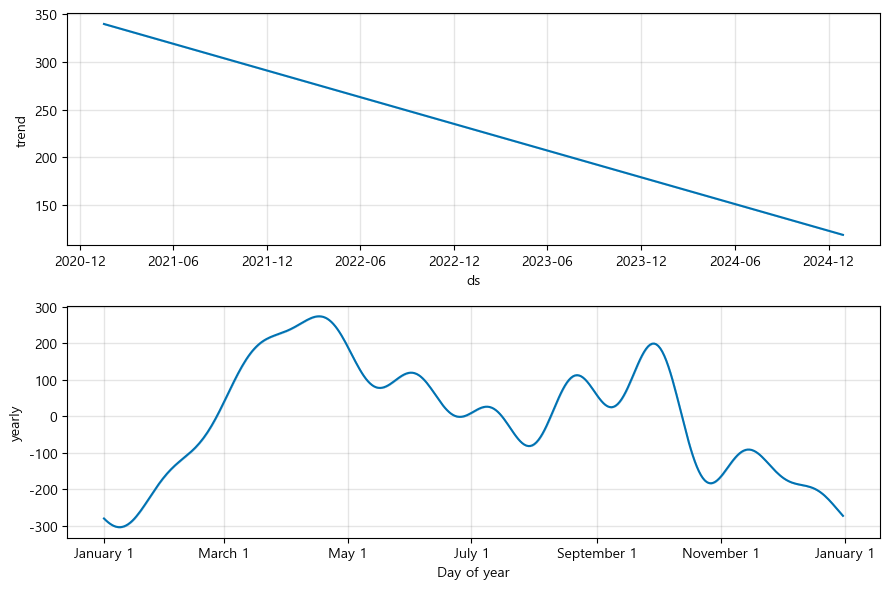

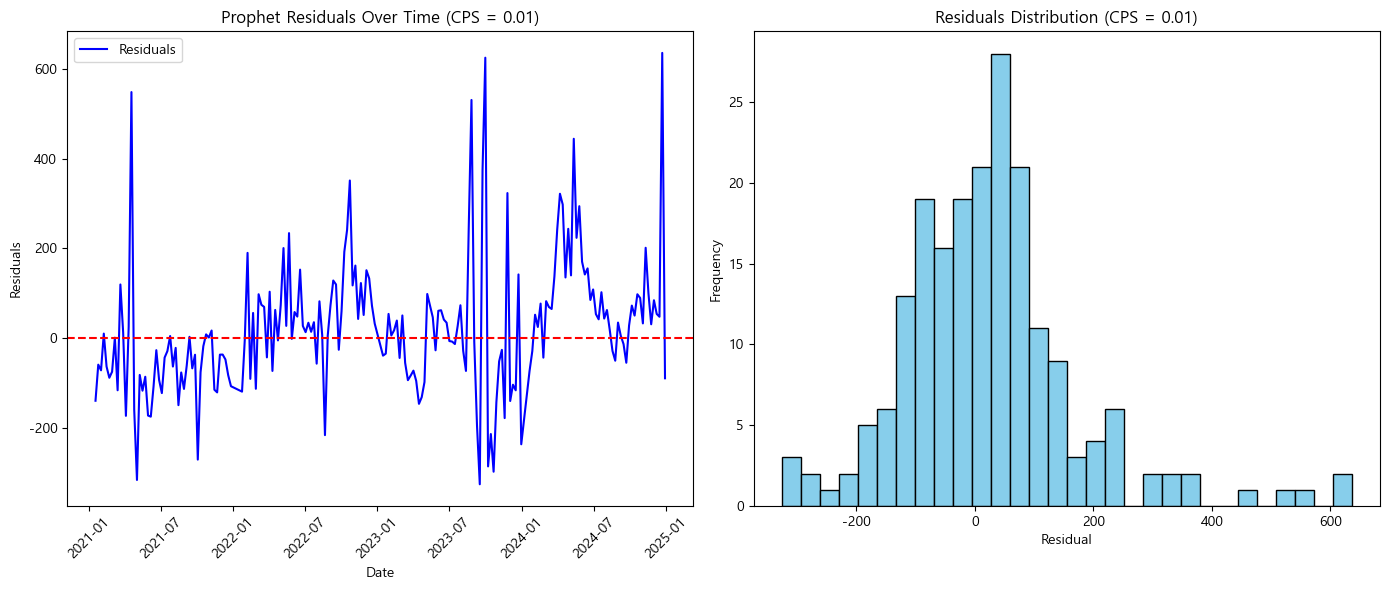


📊 Ljung-Box Test Results:
      lb_stat     lb_pvalue
10  84.743872  5.863441e-14


In [166]:
from statsmodels.stats.diagnostic import acorr_ljungbox
import matplotlib.pyplot as plt

# 🔥 최적의 changepoint_prior_scale 값으로 Prophet 다시 학습
m_best = Prophet(changepoint_prior_scale=0.01, yearly_seasonality=True, seasonality_mode='multiplicative')
m_best.fit(train_data)

# 최적 모델 예측
future_best = m.make_future_dataframe(periods=52, freq='W')
forecast_best = m_best.predict(future_best)

# 원래 데이터에 예측값 yhat을 ds 기준으로 inner 조인
merged_data = pd.merge(denim_pants_df[['ds', 'y']], forecast_best[['ds', 'yhat']], on='ds', how='inner')

# 잔차 계산
merged_data['residual'] = merged_data['y'] - merged_data['yhat']

m.plot_components(forecast_best); #추세선과 연간계절성 시각화

# ✅ 서브플롯 설정 (2개 그래프 나란히 배치)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 📌 (왼쪽) 잔차 시각화
axes[0].plot(merged_data['ds'], merged_data['residual'], label='Residuals', color='blue')
axes[0].axhline(y=0, color='r', linestyle='--')
axes[0].set_title('Prophet Residuals Over Time (CPS = 0.01)')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Residuals')
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend()

# 📌 (오른쪽) 잔차 히스토그램
axes[1].hist(merged_data['residual'], bins=30, edgecolor='black', color='skyblue')
axes[1].set_title('Residuals Distribution (CPS = 0.01)')
axes[1].set_xlabel('Residual')
axes[1].set_ylabel('Frequency')

# 서브플롯 레이아웃 조정
plt.tight_layout()
plt.show()

# ✅ Ljung-Box 테스트 (잔차가 랜덤한지 확인)
ljung_test = acorr_ljungbox(merged_data['residual'], lags=[10], return_df=True)
print("\n📊 Ljung-Box Test Results:")
print(ljung_test)


### Prophet 할인율, 기온 외생변수 추가ver.

In [168]:
denim_pants = df[df['카테고리']=='사계절_데님_데님팬츠_ZB']
denim_pants

,기획년도,주차,카테고리,라인,시즌이월,시즌,복종,소품종,성별,총입고수량,...,누적판매수량,누적판매액,누적매출원가,누적판매택가,누적판매율,ROI,평균기온(도),1시간 최다강수량(mm),일 최심신적설(cm),평균 날씨
46,2021,2021-01-17,사계절_데님_데님팬츠_ZB,ZB,01_시즌,사계절,데님,데님팬츠,1:남성,6147,...,47,3658470,550864,3755300,0.76,0.04,-1.8,NaN,2.6,눈
70,2021,2021-01-24,사계절_데님_데님팬츠_ZB,ZB,01_시즌,사계절,데님,데님팬츠,1:남성,10609,...,125,9569170,1465063,9987500,1.18,0.06,2.1,NaN,0.9,눈
95,2021,2021-01-31,사계절_데님_데님팬츠_ZB,ZB,01_시즌,사계절,데님,데님팬츠,1:남성,10609,...,192,14406233,2250337,15340800,1.81,0.09,0.7,NaN,2.2,눈
132,2021,2021-02-07,사계절_데님_데님팬츠_ZB,ZB,01_시즌,사계절,데님,데님팬츠,1:남성,10609,...,389,27580653,4559275,31081100,3.67,0.16,0.6,NaN,2.2,눈
169,2021,2021-02-14,사계절_데님_데님팬츠_ZB,ZB,01_시즌,사계절,데님,데님팬츠,1:남성,10609,...,575,41067363,6739288,45942500,5.42,0.25,4.1,NaN,NaN,맑음
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8679,2024,2024-12-01,사계절_데님_데님팬츠_ZB,ZB,01_시즌,사계절,데님,데님팬츠,1:남성,16214,...,11464,536366695,169793604,1134936000,70.70,1.24,3.5,NaN,9.6,강한 눈
8719,2024,2024-12-08,사계절_데님_데님팬츠_ZB,ZB,01_시즌,사계절,데님,데님팬츠,1:남성,16214,...,11592,542166725,171814255,1147608000,71.49,1.25,2.4,NaN,NaN,맑음
8761,2024,2024-12-15,사계절_데님_데님팬츠_ZB,ZB,01_시즌,사계절,데님,데님팬츠,1:남성,16214,...,11705,547355401,173598111,1158795000,72.19,1.27,1.2,NaN,NaN,맑음
8797,2024,2024-12-22,사계절_데님_데님팬츠_ZB,ZB,01_시즌,사계절,데님,데님팬츠,1:남성,16214,...,12415,577033401,184806171,1229085000,76.57,1.33,-1.2,NaN,1.4,눈


In [ ]:
# ✅ 1. 전체 주차 생성 (21년 1월 첫째 주 ~ 24년 12월 마지막 주)
all_weeks = pd.date_range(start='2021-01-03', end='2024-12-29', freq='W-SUN')
all_weeks_df = pd.DataFrame({'ds': all_weeks})  # Prophet을 위해 컬럼명 'ds'로 설정

# ✅ 2. 기존 데이터 '주차'를 datetime 형식으로 변환
denim_pants['ds'] = pd.to_datetime(denim_pants['주차'])

# ✅ 3. 'ds' 기준으로 모든 주차와 기존 데이터를 병합
merged_data = all_weeks_df.merge(denim_pants, on='ds', how='left')

# ✅ 4. 누락된 값 채우기
merged_data['판매수량'] = merged_data['누적판매수량'].fillna(0)  # 누락된 주차는 판매수량 0
merged_data['할인율'] = merged_data['할인율'].fillna(0)  # 할인율 0으로 채우기

# ✅ 5. 해당 주차의 평균 기온을 `df`에서 가져와서 '기온' 컬럼으로 추가
df['주차'] = pd.to_datetime(df['주차'])  # 원본 데이터 '주차'도 datetime 형식 변환
weekly_temp = df.groupby('주차')['평균기온(도)'].mean().reset_index()  # 주차별 평균 기온 계산
weekly_temp.columns = ['ds', '기온']  # 컬럼명 변경

# ✅ 6. 기온 데이터 병합
merged_data = merged_data.merge(weekly_temp, on='ds', how='left')

# ✅ 7. 정리 (필요한 컬럼만 유지)
final_data = merged_data[['ds', '판매수량', '할인율', '기온']]
final_data.columns = ['ds', 'y', '할인율', '기온']  # Prophet용 컬럼명 설정

# ✅ 8. 데이터 확인
import ace_tools as tools
tools.display_dataframe_to_user(name="보정된 denim_pants 데이터", dataframe=final_data)
